# XGBoost — Arrival and Within Trip Counts (With Weather, Upper Bound)

Extends the departure XGBoost model to `arrival_count` and `within_count`.
Only the **with-weather** feature set is used (realized weather, upper-bound
scenario) — the no-weather comparison is skipped for these targets by request.
Same time-based train/test split as `Predictive_model.ipynb`.

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

df = pd.read_csv('./Data/model_df_with_event_flag.csv')

model_df_clean = df[df['YEAR'] != 2020].copy()

train = model_df_clean[model_df_clean['YEAR'] < 2025].copy()
test = model_df_clean[model_df_clean['YEAR'] == 2025].copy()

features_with_weather = ['HOUR', 'day_of_week', 'MONTH_NUM', 'YEAR', 'event_flag', 'avg_temp', 'avg_precip']

print(f"Train: {len(train)} rows, Test: {len(test)} rows")

Train: 8059 rows, Test: 2207 rows


In [ ]:
def fit_and_evaluate_xgb(target, train, test, features):
    """Fit an XGBoost Poisson regressor for `target` on train, evaluate MAE/RMSE/R2 on test."""
    X_train, y_train = train[features], train[target]
    X_test, y_test = test[features], test[target]

    model = xgb.XGBRegressor(objective='count:poisson', n_estimators=200, max_depth=5, learning_rate=0.05)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"--- XGBoost (with weather): {target} ---")
    print(f"  MAE:  {mae:.1f}")
    print(f"  RMSE: {rmse:.1f}")
    print(f"  R2:   {r2:.3f}\n")

    return model, preds, {'target': target, 'mae': mae, 'rmse': rmse, 'r2': r2}

## Arrival count

In [ ]:
model_arr, preds_arr, arr_results = fit_and_evaluate_xgb('arrival_count', train, test, features_with_weather)

importance_arr = pd.Series(model_arr.feature_importances_, index=features_with_weather).sort_values(ascending=False)
print(importance_arr)

--- XGBoost (with weather): arrival_count ---
  MAE:  133.3
  RMSE: 176.0
  R2:   0.848

HOUR           0.580668
day_of_week    0.181417
event_flag     0.100714
YEAR           0.079170
avg_precip     0.021724
MONTH_NUM      0.021347
avg_temp       0.014962
dtype: float32


## Within count

In [ ]:
model_within, preds_within, within_results = fit_and_evaluate_xgb('within_count', train, test, features_with_weather)

importance_within = pd.Series(model_within.feature_importances_, index=features_with_weather).sort_values(ascending=False)
print(importance_within)

--- XGBoost (with weather): within_count ---
  MAE:  33.0
  RMSE: 48.1
  R2:   0.779

HOUR           0.572923
day_of_week    0.169788
YEAR           0.098090
event_flag     0.080416
avg_precip     0.045227
MONTH_NUM      0.018312
avg_temp       0.015244
dtype: float32


### Departure Count

In [ ]:
model_dep, preds_dep, dep_results = fit_and_evaluate_xgb('departure_count', train, test, features_with_weather)

importance_dep = pd.Series(model_dep.feature_importances_, index=features_with_weather).sort_values(ascending=False)
print(importance_dep)

--- XGBoost (with weather): departure_count ---
  MAE:  137.9
  RMSE: 197.0
  R2:   0.854

HOUR           0.543165
day_of_week    0.247860
YEAR           0.076785
event_flag     0.059605
MONTH_NUM      0.034542
avg_precip     0.022568
avg_temp       0.015475
dtype: float32


## Actual vs predicted (per month, test year)

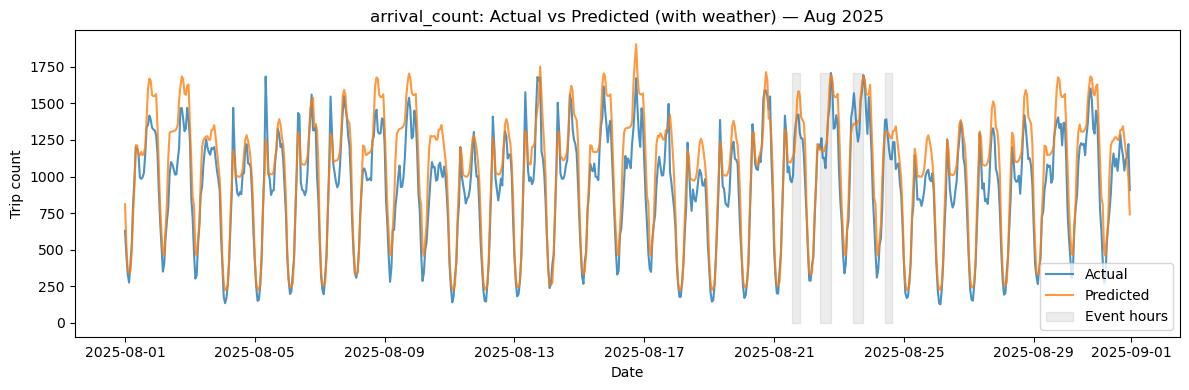

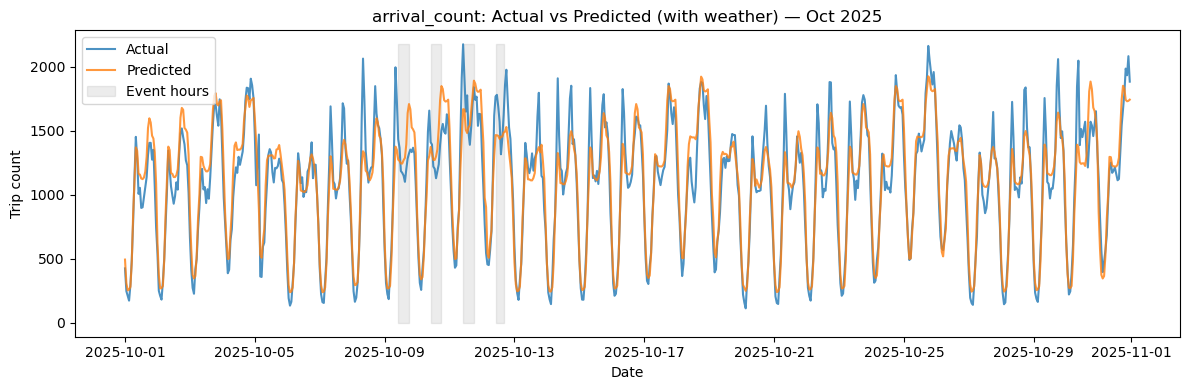

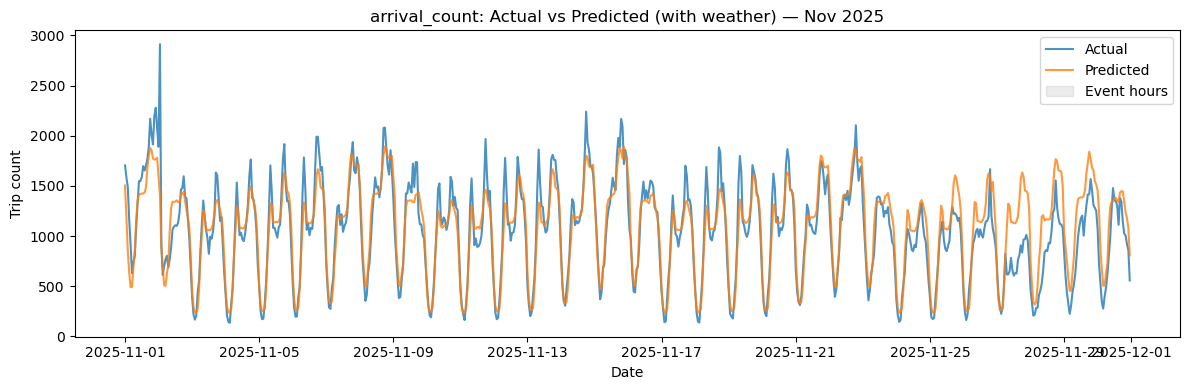

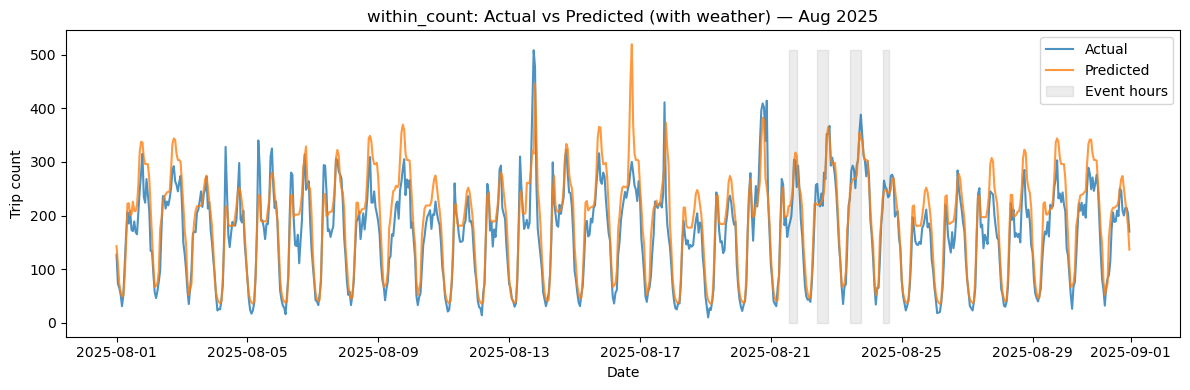

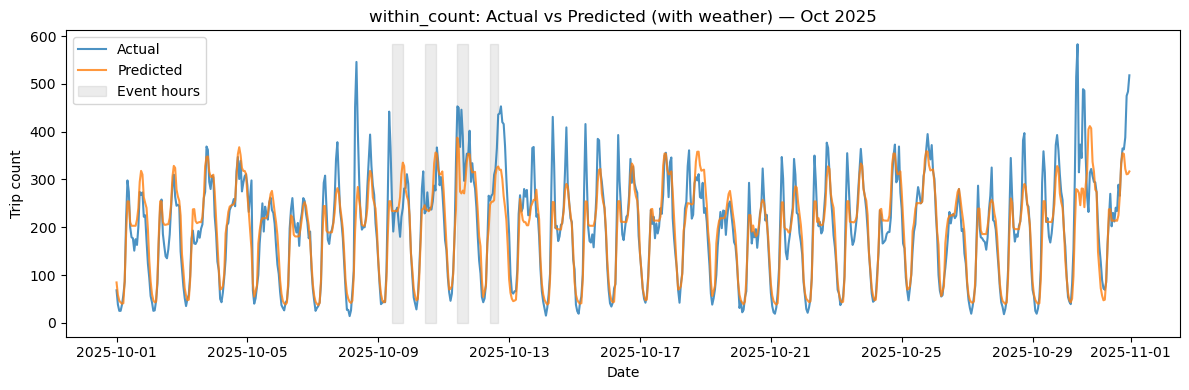

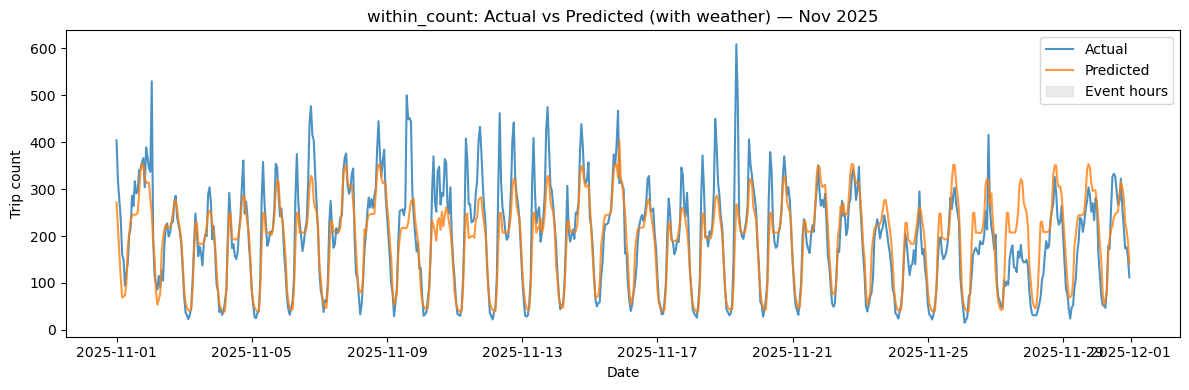

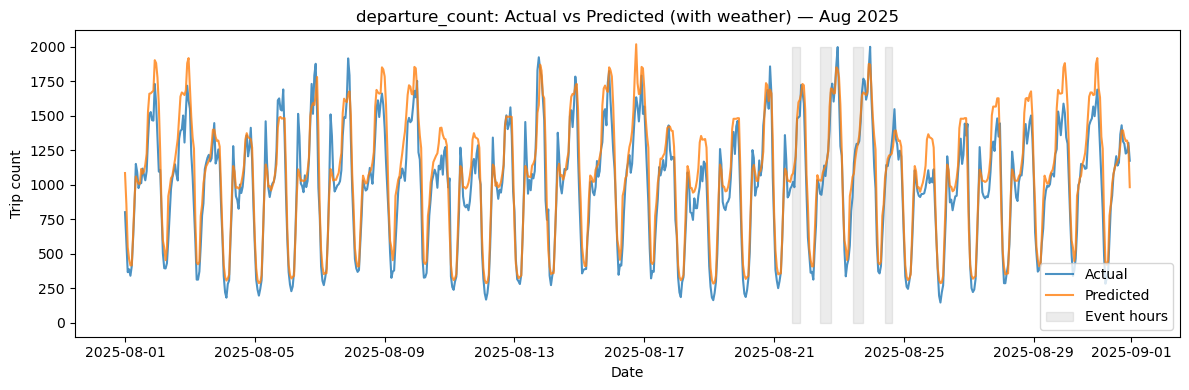

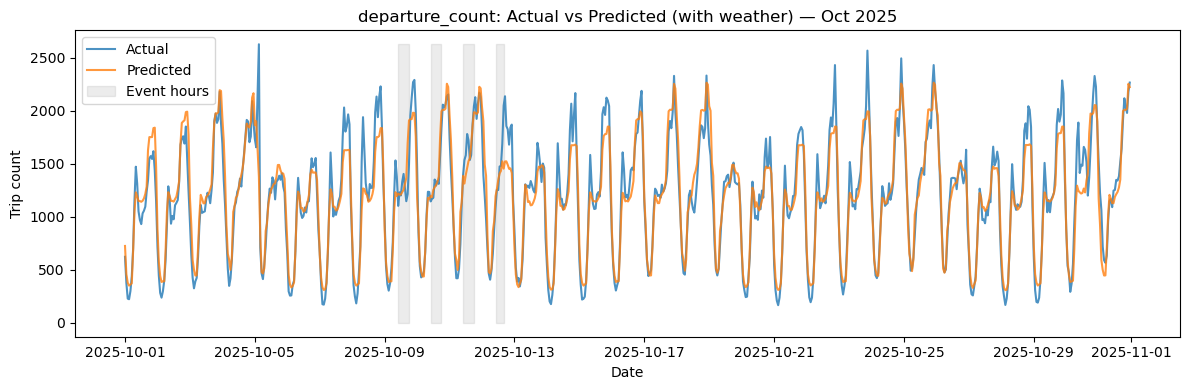

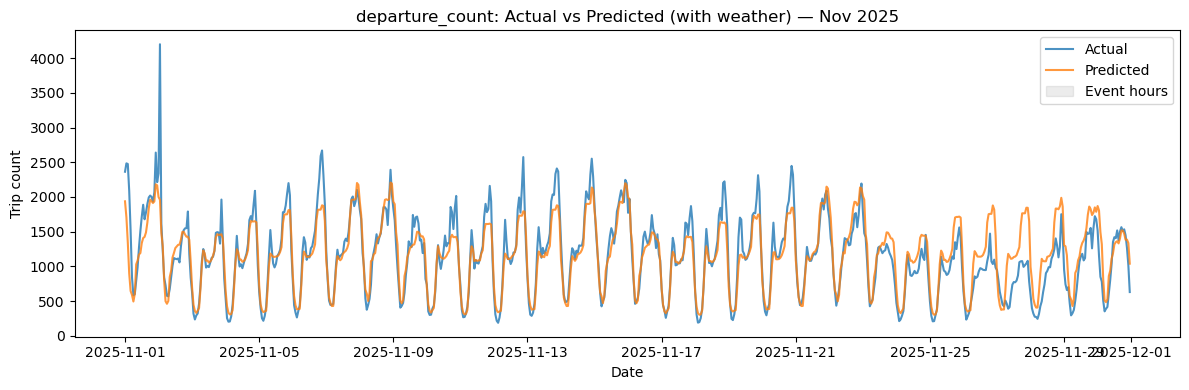

In [ ]:
import matplotlib.pyplot as plt

def plot_actual_vs_predicted(target, preds, test, out_prefix):
    test_plot = test.copy()
    test_plot['predicted'] = preds
    test_plot['datetime'] = pd.to_datetime(
        test_plot[['YEAR', 'MONTH_NUM', 'DAY', 'HOUR']]
        .rename(columns={'YEAR': 'year', 'MONTH_NUM': 'month', 'DAY': 'day', 'HOUR': 'hour'})
    )
    test_plot = test_plot.sort_values('datetime')

    combos = test_plot[['YEAR', 'MONTH_NUM', 'MONTH']].drop_duplicates().sort_values(['YEAR', 'MONTH_NUM'])

    for _, row in combos.iterrows():
        yr, mnum, mname = row['YEAR'], row['MONTH_NUM'], row['MONTH']
        sub = test_plot[(test_plot['YEAR'] == yr) & (test_plot['MONTH_NUM'] == mnum)]

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(sub['datetime'], sub[target], label='Actual', color='tab:blue', alpha=0.8)
        ax.plot(sub['datetime'], sub['predicted'], label='Predicted', color='tab:orange', alpha=0.8)

        event_mask = sub['event_flag'] == 1
        ax.fill_between(sub['datetime'], 0, sub[target].max(),
                         where=event_mask, color='gray', alpha=0.15, label='Event hours')

        ax.set_title(f'{target}: Actual vs Predicted (with weather) — {mname} {yr}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Trip count')
        ax.legend()
        plt.tight_layout()

        out_path = f'Data/plots/{out_prefix}_{yr}_{mname}.png'
        plt.savefig(out_path, dpi=150)
        plt.show()

plot_actual_vs_predicted('arrival_count', preds_arr, test, 'actual_vs_predicted_arrival')
plot_actual_vs_predicted('within_count', preds_within, test, 'actual_vs_predicted_within')
plot_actual_vs_predicted('departure_count', preds_dep, test, 'actual_vs_predicted_departure')

## Combined results table

In [ ]:
results_df = pd.DataFrame([arr_results, within_results, dep_results])
results_df

,target,mae,rmse,r2
0,arrival_count,133.296997,175.979492,0.847777
1,within_count,32.973152,48.064728,0.779192
2,departure_count,137.899612,197.047836,0.854234
